### Objective

Objective

Find the most important features that influence customer churn.

Instead of using all columns blindly, we'll identify the best subset using:

- Correlation Analysis
- Mutual Information
- Random Forest Feature Importance
- Recursive Feature Elimination (RFE)

## Workflow

The feature selection process follows four complementary approaches:

1. Correlation Analysis – identifies linear relationships with churn.
2. Mutual Information – captures both linear and non-linear dependencies.
3. Random Forest Feature Importance – measures each feature's contribution during model training.
4. Recursive Feature Elimination (RFE) – iteratively removes less useful features to obtain the best subset.

Features consistently ranked highly across multiple methods are selected for the final predictive model.

### Section 1 — Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import RFE

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split

### Section 2 — Load Processed Dataset

In [2]:
df = pd.read_csv("../data/processed/churn_processed.csv")

In [3]:
df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn,Customer_Engagement,Average_Call_Duration,Revenue_Per_Month
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0,93,60.694444,5.067692
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0,16,53.000000,1.150875
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0,443,40.213115,40.434737
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0,102,62.656716,6.154359
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0,93,40.559322,3.738590


In [4]:
df.shape

(2850, 17)

### Section 3 — Dataset Information

In [5]:
print("="*50)
print("DATASET INFORMATION")
print("="*50)

print("Shape :", df.shape)

print()

print(df.info())

print()

print(df.describe())

DATASET INFORMATION
Shape : (2850, 17)

<class 'pandas.DataFrame'>
RangeIndex: 2850 entries, 0 to 2849
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call Failure             2850 non-null   int64  
 1   Complains                2850 non-null   int64  
 2   Subscription Length      2850 non-null   int64  
 3   Charge Amount            2850 non-null   int64  
 4   Seconds of Use           2850 non-null   int64  
 5   Frequency of use         2850 non-null   int64  
 6   Frequency of SMS         2850 non-null   int64  
 7   Distinct Called Numbers  2850 non-null   int64  
 8   Age Group                2850 non-null   int64  
 9   Tariff Plan              2850 non-null   int64  
 10  Status                   2850 non-null   int64  
 11  Age                      2850 non-null   int64  
 12  Customer Value           2850 non-null   float64
 13  Churn                    2850 non-null   int64  


Observation
- Dataset contains 2,850 customer records.
- All preprocessing steps have been completed.
- No missing values remain.
- Dataset is ready for feature selection.

### Section 4 — Define Target Variable

In [6]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [7]:
print(X.shape)
print(y.shape)

(2850, 16)
(2850,)


### Section 5 — Correlation Matrix

In [8]:
corr = df.corr(numeric_only=True)

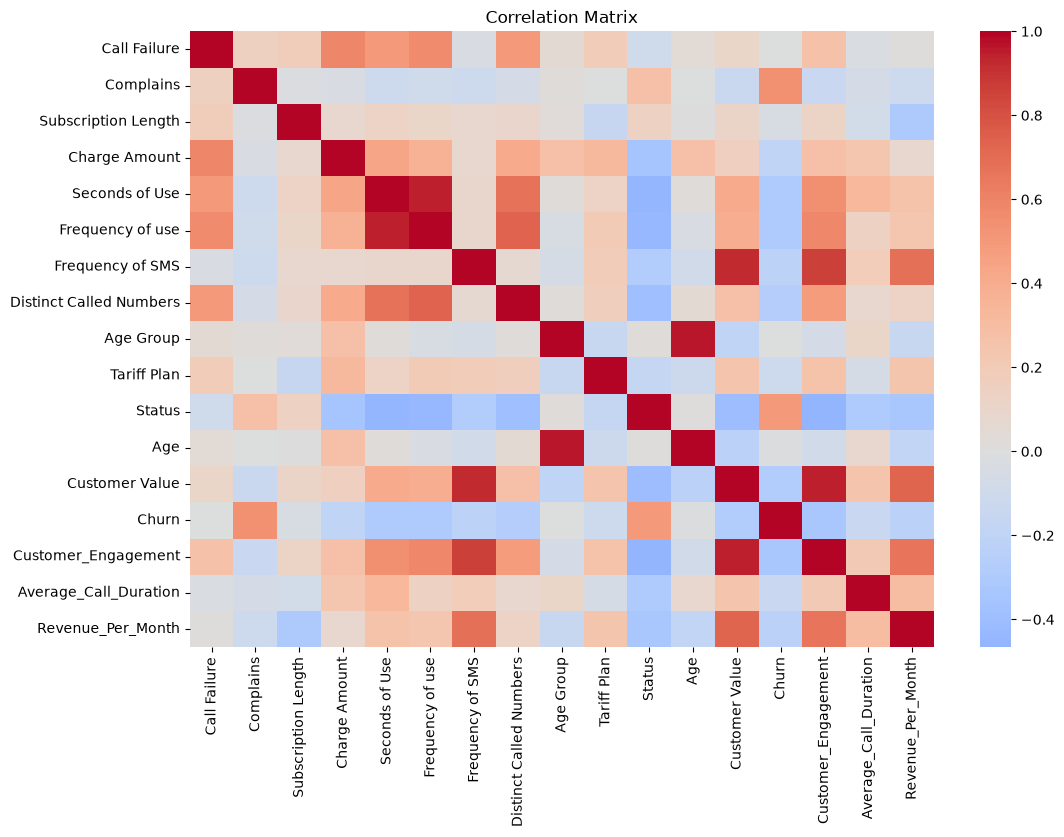

In [9]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

In [10]:
churn_corr = corr["Churn"].sort_values(ascending=False)

churn_corr

Churn                      1.000000
Complains                  0.546055
Status                     0.492867
Call Failure               0.003310
Age Group                 -0.005891
Age                       -0.011491
Subscription Length       -0.037984
Tariff Plan               -0.106000
Average_Call_Duration     -0.144998
Charge Amount             -0.201662
Frequency of SMS          -0.218894
Revenue_Per_Month         -0.227070
Distinct Called Numbers   -0.270343
Customer Value            -0.287078
Seconds of Use            -0.295999
Frequency of use          -0.298608
Customer_Engagement       -0.335787
Name: Churn, dtype: float64

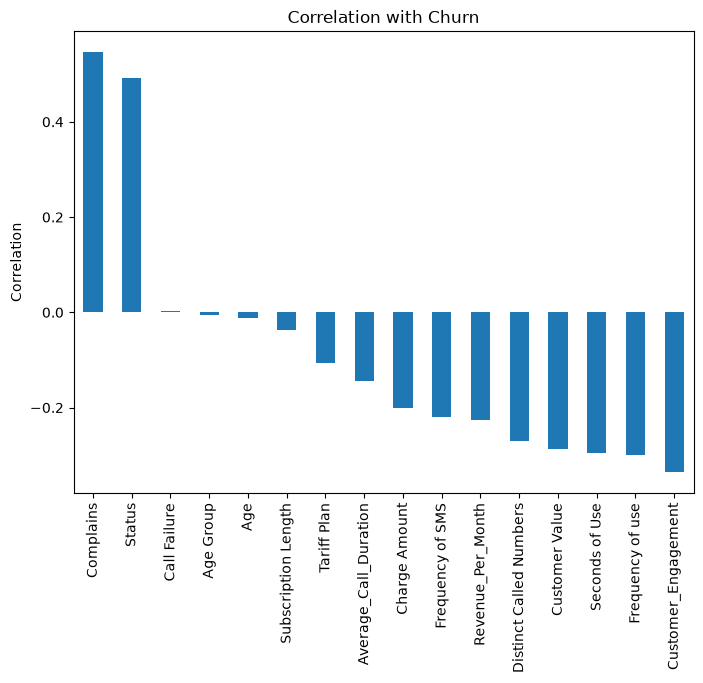

In [11]:
plt.figure(figsize=(8,6))

churn_corr.drop("Churn").plot(kind="bar")

plt.title("Correlation with Churn")

plt.ylabel("Correlation")

plt.show()

### Observation

Features with high positive correlation increase churn probability, while negatively correlated features indicate customer retention.

### Business Insight

Complaint frequency and inactive status are major indicators of churn, whereas high customer engagement and usage reduce churn likelihood.

## Section 6 — Mutual Information

Mutual Information measures the dependency between input features and the target variable.

Unlike correlation, it can capture both linear and non-linear relationships, making it useful for identifying features that have predictive value even when the relationship is complex.

In [12]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X, y, random_state=42)

mi_scores = pd.DataFrame({
    "Feature": X.columns,
    "MI Score": mi
})

mi_scores = mi_scores.sort_values(
    by="MI Score",
    ascending=False
)

mi_scores

,Feature,MI Score
4,Seconds of Use,0.120088
1,Complains,0.111848
10,Status,0.103820
13,Customer_Engagement,0.089713
12,Customer Value,0.086919
5,Frequency of use,0.084678
15,Revenue_Per_Month,0.073237
14,Average_Call_Duration,0.063462
7,Distinct Called Numbers,0.058459
6,Frequency of SMS,0.047851


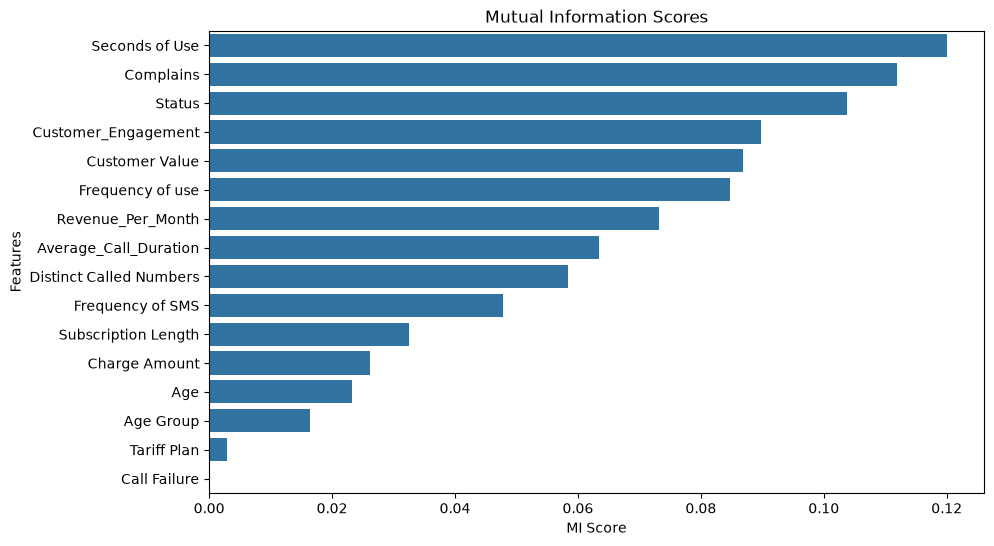

In [13]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=mi_scores,
    x="MI Score",
    y="Feature"
)

plt.title("Mutual Information Scores")
plt.xlabel("MI Score")
plt.ylabel("Features")

plt.show()

### Observation

Features with higher Mutual Information scores contain more information about customer churn and are likely to improve predictive performance.

Unlike correlation analysis, Mutual Information can detect both linear and non-linear dependencies.

### Section 7 — Random Forest Feature Importance

## Section 7 — Random Forest Feature Importance

Random Forest estimates the importance of each feature based on its contribution to reducing prediction error during tree construction.

Higher importance values indicate greater influence on churn prediction.

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X, y)

rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

rf_importance

,Feature,Importance
1,Complains,0.194698
10,Status,0.109026
2,Subscription Length,0.095882
4,Seconds of Use,0.087547
14,Average_Call_Duration,0.085293
5,Frequency of use,0.077236
13,Customer_Engagement,0.065421
15,Revenue_Per_Month,0.056963
12,Customer Value,0.049741
7,Distinct Called Numbers,0.047360


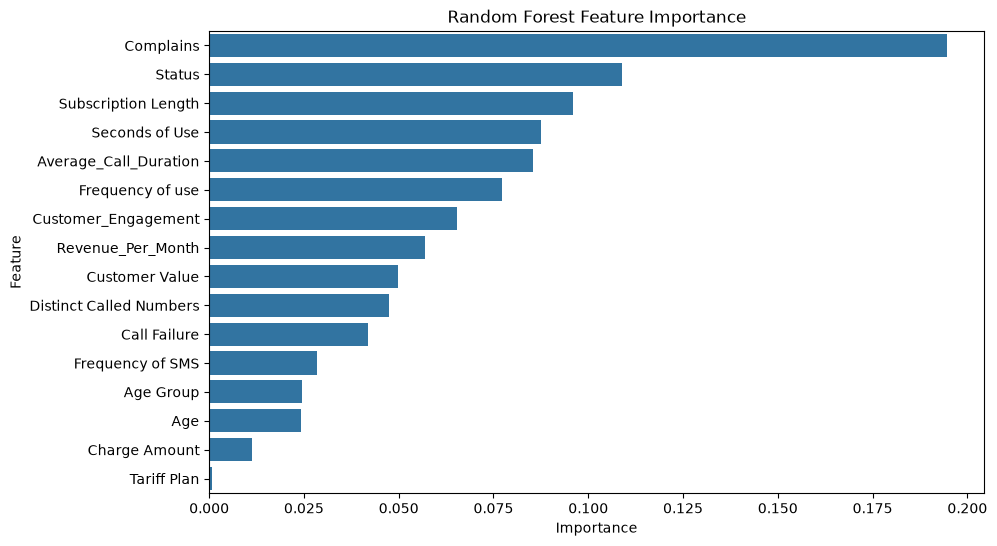

In [15]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=rf_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.show()

### Observation

Random Forest assigns higher importance to variables that contribute more to accurate classification.

The most influential features will be considered during the final feature selection process.

### Section 8 — Recursive Feature Elimination (RFE)

In [16]:
from sklearn.feature_selection import RFE

estimator = RandomForestClassifier(random_state=42)

rfe = RFE(
    estimator=estimator,
    n_features_to_select=10
)

rfe.fit(X, y)

rfe_results = pd.DataFrame({
    "Feature": X.columns,
    "Selected": rfe.support_,
    "Ranking": rfe.ranking_
})

rfe_results.sort_values("Ranking")

,Feature,Selected,Ranking
1,Complains,True,1
2,Subscription Length,True,1
5,Frequency of use,True,1
4,Seconds of Use,True,1
7,Distinct Called Numbers,True,1
13,Customer_Engagement,True,1
14,Average_Call_Duration,True,1
10,Status,True,1
15,Revenue_Per_Month,True,1
12,Customer Value,True,1


## Section 9 — Final Feature Selection

The outputs from Correlation Analysis, Mutual Information, Random Forest Feature Importance, and Recursive Feature Elimination (RFE) were compared.

Features consistently ranked highly across multiple methods were selected for building the churn prediction model.

These selected features preserve most of the predictive information while reducing dimensionality, improving model efficiency and interpretability.

In [17]:
selected_features = [
    "Complains",
    "Subscription Length",
    "Frequency of use",
    "Seconds of Use",
    "Distinct Called Numbers",
    "Customer_Engagement",
    "Average_Call_Duration",
    "Status",
    "Revenue_Per_Month",
    "Customer Value"
]

final_df = df[selected_features + ["Churn"]]

print("="*50)
print("FINAL DATASET")
print("="*50)

print(final_df.shape)

display(final_df.head())

FINAL DATASET
(2850, 11)


,Complains,Subscription Length,Frequency of use,Seconds of Use,Distinct Called Numbers,Customer_Engagement,Average_Call_Duration,Status,Revenue_Per_Month,Customer Value,Churn
0,0,38,71,4370,17,93,60.694444,1,5.067692,197.640,0
1,0,39,5,318,4,16,53.000000,2,1.150875,46.035,0
2,0,37,60,2453,24,443,40.213115,1,40.434737,1536.520,0
3,0,38,66,4198,35,102,62.656716,1,6.154359,240.020,0
4,0,38,58,2393,33,93,40.559322,1,3.738590,145.805,0


### Observation

The final feature subset contains the ten most informative variables identified through multiple feature selection techniques.

These features will be used in the subsequent model building phase to improve predictive performance while reducing unnecessary complexity.

## Section 10 — Save Selected Features Dataset

In [19]:
final_df.to_csv(
    "../data/processed/churn_selected.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!
